<a href="https://colab.research.google.com/github/meghanagogineni2005-svg/data-science-python-internship/blob/main/Week3_Statistical_Analysis_and_Hypothesis_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from ucimlrepo import fetch_ucirepo

# Fetch the UCI Student Performance dataset
student_performance = fetch_ucirepo(id=320)

# Get the data
X = student_performance.data.features
y = student_performance.data.targets

# Combine features and target
df = pd.concat([X, y], axis=1)

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (649, 33)


In [ ]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [ ]:
print("Data Types:")
print(df.dtypes)

Data Types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object


In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [ ]:
print("Sex:")
print(df["sex"].value_counts())

print("\nStudy Time:")
print(df["studytime"].value_counts().sort_index())

print("\nInternet Access:")
print(df["internet"].value_counts())

print("\nHigher Education:")
print(df["higher"].value_counts())

print("\nFinal Grade (G3):")
print(df["G3"].describe())

Sex:
sex
F    383
M    266
Name: count, dtype: int64

Study Time:
studytime
1    212
2    305
3     97
4     35
Name: count, dtype: int64

Internet Access:
internet
yes    498
no     151
Name: count, dtype: int64

Higher Education:
higher
yes    580
no      69
Name: count, dtype: int64

Final Grade (G3):
count    649.000000
mean      11.906009
std        3.230656
min        0.000000
25%       10.000000
50%       12.000000
75%       14.000000
max       19.000000
Name: G3, dtype: float64


In [ ]:
gender_stats = df.groupby("sex")["G3"].agg(
    ["count", "mean", "std"]
)

print("Final Grade by Gender:")
print(gender_stats)

Final Grade by Gender:
     count       mean       std
sex                            
F      383  12.253264  3.124147
M      266  11.406015  3.320690


In [ ]:
studytime_stats = df.groupby("studytime")["G3"].agg(
    ["count", "mean", "std"]
)

print("Final Grade by Study Time:")
print(studytime_stats)

Final Grade by Study Time:
           count       mean       std
studytime                            
1            212  10.844340  3.218624
2            305  12.091803  3.243125
3             97  13.226804  2.502104
4             35  13.057143  3.038410


In [ ]:
internet_higher_table = pd.crosstab(
    df["internet"],
    df["higher"]
)

print("Internet Access vs Higher Education:")
print(internet_higher_table)

Internet Access vs Higher Education:
higher    no  yes
internet         
no        22  129
yes       47  451


In [ ]:
female_grades = df[df["sex"] == "F"]["G3"]
male_grades = df[df["sex"] == "M"]["G3"]

t_stat, p_value = stats.ttest_ind(
    female_grades,
    male_grades,
    equal_var=False
)

print("Independent Two-Sample t-Test")
print("t-statistic:", t_stat)
print("p-value:", p_value)

Independent Two-Sample t-Test
t-statistic: 3.274707393354231
p-value: 0.0011245651360440646


In [ ]:
mean_difference = female_grades.mean() - male_grades.mean()

se = np.sqrt(
    female_grades.var(ddof=1) / len(female_grades)
    +
    male_grades.var(ddof=1) / len(male_grades)
)

df_welch = (
    (female_grades.var(ddof=1) / len(female_grades)
     + male_grades.var(ddof=1) / len(male_grades)) ** 2
    /
    (
        (female_grades.var(ddof=1) / len(female_grades)) ** 2
        / (len(female_grades) - 1)
        +
        (male_grades.var(ddof=1) / len(male_grades)) ** 2
        / (len(male_grades) - 1)
    )
)

critical_value = stats.t.ppf(
    0.975,
    df_welch
)

margin_of_error = critical_value * se

ci_lower = mean_difference - margin_of_error
ci_upper = mean_difference + margin_of_error

print("Mean difference (Female - Male):", mean_difference)
print("95% Confidence Interval:", (ci_lower, ci_upper))

Mean difference (Female - Male): 0.8472486699778159
95% Confidence Interval: (np.float64(0.339033390009585), np.float64(1.3554639499460468))


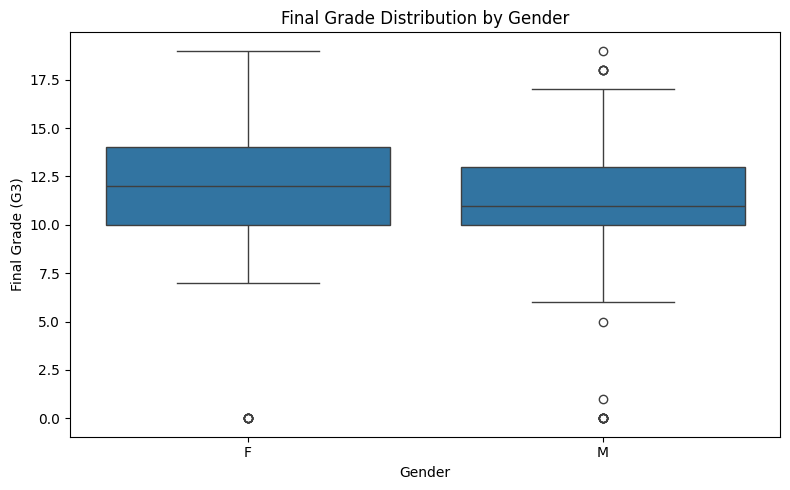

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="sex",
    y="G3"
)

plt.title("Final Grade Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Final Grade (G3)")

plt.tight_layout()
plt.show()

In [ ]:
group1 = df[df["studytime"] == 1]["G3"]
group2 = df[df["studytime"] == 2]["G3"]
group3 = df[df["studytime"] == 3]["G3"]
group4 = df[df["studytime"] == 4]["G3"]

f_stat, p_value_anova = stats.f_oneway(
    group1,
    group2,
    group3,
    group4
)

print("One-Way ANOVA")
print("F-statistic:", f_stat)
print("p-value:", p_value_anova)

One-Way ANOVA
F-statistic: 15.876267993177123
p-value: 5.705728458962843e-10


In [ ]:
study_groups = [
    df[df["studytime"] == 1]["G3"],
    df[df["studytime"] == 2]["G3"],
    df[df["studytime"] == 3]["G3"],
    df[df["studytime"] == 4]["G3"]
]

group_names = [
    "Less than 2 hours",
    "2 to 5 hours",
    "5 to 10 hours",
    "More than 10 hours"
]

for name, group in zip(group_names, study_groups):
    mean = group.mean()
    se = stats.sem(group)
    ci = stats.t.interval(
        0.95,
        len(group) - 1,
        loc=mean,
        scale=se
    )

    print(name)
    print("Mean:", mean)
    print("95% Confidence Interval:", ci)
    print()

Less than 2 hours
Mean: 10.84433962264151
95% Confidence Interval: (np.float64(10.408578393908945), np.float64(11.280100851374074))

2 to 5 hours
Mean: 12.091803278688525
95% Confidence Interval: (np.float64(11.726381587069131), np.float64(12.45722497030792))

5 to 10 hours
Mean: 13.22680412371134
95% Confidence Interval: (np.float64(12.722518536663795), np.float64(13.731089710758884))

More than 10 hours
Mean: 13.057142857142857
95% Confidence Interval: (np.float64(12.013412648713118), np.float64(14.100873065572596))



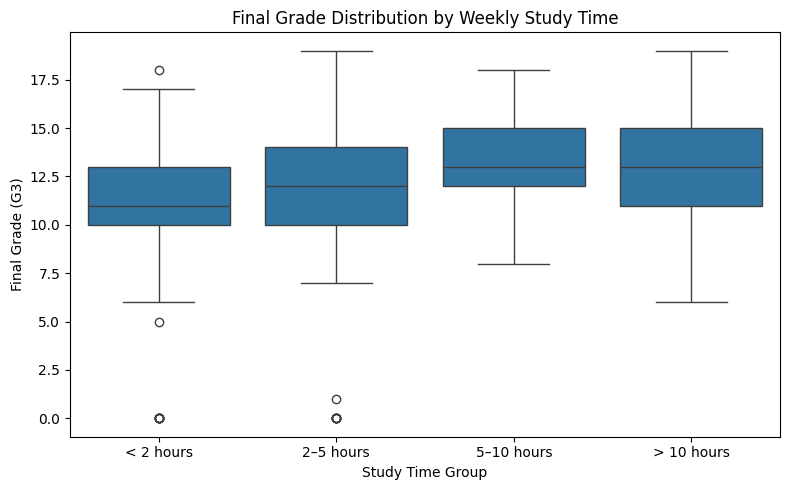

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="studytime",
    y="G3"
)

plt.title("Final Grade Distribution by Weekly Study Time")
plt.xlabel("Study Time Group")
plt.ylabel("Final Grade (G3)")

plt.xticks(
    [0, 1, 2, 3],
    ["< 2 hours", "2–5 hours", "5–10 hours", "> 10 hours"]
)

plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [ ]:
tukey_result = pairwise_tukeyhsd(
    endog=df["G3"],
    groups=df["studytime"],
    alpha=0.05
)

print(tukey_result)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2   1.2475 0.0001  0.5278 1.9672   True
     1      3   2.3825    0.0  1.3958 3.3691   True
     1      4   2.2128 0.0007  0.7443 3.6813   True
     2      3    1.135 0.0103  0.1968 2.0732   True
     2      4   0.9653 0.3084 -0.4711 2.4018  False
     3      4  -0.1697 0.9927 -1.7567 1.4174  False
---------------------------------------------------


In [ ]:
chi2_stat, p_value_chi2, dof, expected = stats.chi2_contingency(
    internet_higher_table
)

print("Chi-Square Test of Independence")
print("Chi-square statistic:", chi2_stat)
print("p-value:", p_value_chi2)
print("Degrees of freedom:", dof)

Chi-Square Test of Independence
Chi-square statistic: 2.6941222240584533
p-value: 0.10071894310832907
Degrees of freedom: 1


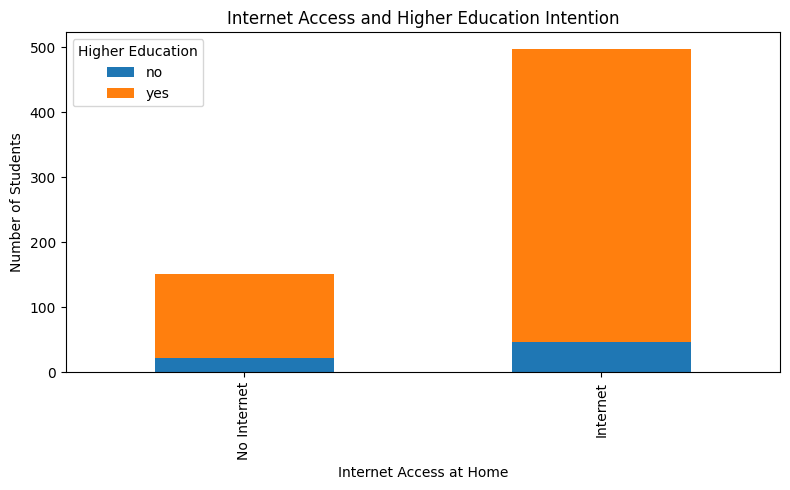

In [ ]:
internet_higher_table.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Internet Access and Higher Education Intention")
plt.xlabel("Internet Access at Home")
plt.ylabel("Number of Students")

plt.xticks(
    [0, 1],
    ["No Internet", "Internet"]
)

plt.legend(title="Higher Education")

plt.tight_layout()
plt.show()

In [ ]:
print("Expected Frequencies:")
print(pd.DataFrame(
    expected,
    index=internet_higher_table.index,
    columns=internet_higher_table.columns
))

Expected Frequencies:
higher           no         yes
internet                       
no        16.053929  134.946071
yes       52.946071  445.053929


In [ ]:
n = internet_higher_table.to_numpy().sum()

cramers_v = np.sqrt(
    chi2_stat / n
)

print("Cramér's V:", cramers_v)

Cramér's V: 0.06442972813522117


In [ ]:
results_summary = pd.DataFrame({
    "Hypothesis": [
        "Gender and Final Grade",
        "Study Time and Final Grade",
        "Internet Access and Higher Education"
    ],
    "Test": [
        "Welch's Independent t-test",
        "One-Way ANOVA",
        "Chi-Square Test of Independence"
    ],
    "Statistic": [
        t_stat,
        f_stat,
        chi2_stat
    ],
    "p_value": [
        p_value,
        p_value_anova,
        p_value_chi2
    ],
    "Conclusion": [
        "Significant difference",
        "Significant difference",
        "Not statistically significant"
    ]
})

results_summary

,Hypothesis,Test,Statistic,p_value,Conclusion
0,Gender and Final Grade,Welch's Independent t-test,3.274707,1.124565e-03,Significant difference
1,Study Time and Final Grade,One-Way ANOVA,15.876268,5.705728e-10,Significant difference
2,Internet Access and Higher Education,Chi-Square Test of Independence,2.694122,1.007189e-01,Not statistically significant


In [ ]:
print("FINAL CONCLUSION")
print("=" * 60)

print("""
This statistical analysis examined factors associated with student
academic performance using three different hypothesis tests.

1. Gender and Final Grade:
The Welch's independent t-test produced a p-value of 0.0011,
indicating a statistically significant difference in mean final
grades between female and male students in this dataset.

2. Study Time and Final Grade:
The one-way ANOVA produced a p-value of approximately 5.71e-10,
indicating statistically significant differences in final grades
across the study-time groups. Tukey's post-hoc test identified
which specific groups differed significantly.

3. Internet Access and Higher Education:
The chi-square test produced a p-value of 0.1007, which is greater
than 0.05. Therefore, the analysis did not provide sufficient
evidence of a statistically significant association between
internet access and intention to pursue higher education.

Overall, the analysis demonstrates how statistical hypothesis
testing can be used to investigate relationships and differences
within real-world educational data. The results describe
associations and group differences in this dataset and should not
be interpreted as proof of causal relationships.
""")

FINAL CONCLUSION

This statistical analysis examined factors associated with student
academic performance using three different hypothesis tests.

1. Gender and Final Grade:
The Welch's independent t-test produced a p-value of 0.0011,
indicating a statistically significant difference in mean final
grades between female and male students in this dataset.

2. Study Time and Final Grade:
The one-way ANOVA produced a p-value of approximately 5.71e-10,
indicating statistically significant differences in final grades
across the study-time groups. Tukey's post-hoc test identified
which specific groups differed significantly.

3. Internet Access and Higher Education:
The chi-square test produced a p-value of 0.1007, which is greater
than 0.05. Therefore, the analysis did not provide sufficient
evidence of a statistically significant association between
internet access and intention to pursue higher education.

Overall, the analysis demonstrates how statistical hypothesis
testing can be used to

In [ ]:
print("LIMITATIONS")
print("=" * 60)

print("""
1. The dataset contains information from students in specific
   Portuguese schools, so the findings may not represent all
   students or educational systems.

2. Statistical significance does not imply causation.

3. The analysis uses observational data, so other factors may
   influence student performance.

4. Study-time categories are self-reported and may contain
   reporting inaccuracies.

5. The analysis considers selected variables and does not include
   every possible factor affecting academic performance.

6. The results should therefore be interpreted within the context
   of this dataset.
""")

LIMITATIONS

1. The dataset contains information from students in specific
   Portuguese schools, so the findings may not represent all
   students or educational systems.

2. Statistical significance does not imply causation.

3. The analysis uses observational data, so other factors may
   influence student performance.

4. Study-time categories are self-reported and may contain
   reporting inaccuracies.

5. The analysis considers selected variables and does not include
   every possible factor affecting academic performance.

6. The results should therefore be interpreted within the context
   of this dataset.

